In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [25]:
df = pd.read_csv("reddit_comments.csv")
df.head()

,post_id,post_title,comment_id,parent_id,author,score,body
0,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt7sbi,t3_1n5j3y0,throwaway6560192,2169,Maybe they want you to do it as an exercise in...
1,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtc2yj,t3_1n5j3y0,Frission_,681,Maybe the point is to show what vulnerabilitie...
2,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt9cor,t3_1n5j3y0,DrShocker,507,Is it concievable they're trying to show you t...
3,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtd4lh,t3_1n5j3y0,COINTELPRO-Relay,432,"Maybe it's some big brain move? Week 1: ""Co..."
4,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtduqf,t3_1n5j3y0,PhilosophicalGoof,101,For a first class assignment? I m guessing thi...


In [26]:
anger = pd.read_csv("anger.txt", sep='\t', header=None, names=['word', 'score'])
anticipation = pd.read_csv("anticipation.txt", sep='\t', header=None, names=['word', 'score'])
disgust = pd.read_csv("disgust.txt", sep='\t', header=None, names=['word', 'score'])
fear = pd.read_csv("fear.txt", sep='\t', header=None, names=['word', 'score'])
joy = pd.read_csv("joy.txt", sep='\t', header=None, names=['word', 'score'])
sadness = pd.read_csv("sadness.txt", sep='\t', header=None, names=['word', 'score'])
surprise = pd.read_csv("surprise.txt", sep='\t', header=None, names=['word', 'score'])
trust = pd.read_csv("trust.txt", sep='\t', header=None, names=['word', 'score'])


anger_lexicon = set(anger[anger["score"] == 1]["word"].astype(str).str.lower().str.strip())
anticipation_lexicon = set(anticipation[anticipation["score"] == 1]["word"].astype(str).str.lower().str.strip())
disgust_lexicon = set(disgust[disgust["score"] == 1]["word"].astype(str).str.lower().str.strip())
fear_lexicon = set(fear[fear["score"] == 1]["word"].astype(str).str.lower().str.strip())
joy_lexicon = set(joy[joy["score"] == 1]["word"].astype(str).str.lower().str.strip())
sadness_lexicon = set(sadness[sadness["score"] == 1]["word"].astype(str).str.lower().str.strip())
surprise_lexicon = set(surprise[surprise["score"] == 1]["word"].astype(str).str.lower().str.strip())
trust_lexicon = set(trust[trust["score"] == 1]["word"].astype(str).str.lower().str.strip())



In [27]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)  # hapus HTML tag
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # hapus karakter non huruf
    text = re.sub(r'([a-zA-Z])\1\1','\1',text) # Hapus duplikasi tiga karakter beruntun
    text = re.sub(r' +',' ',text) # Hapus spasi ganda
    text = re.sub(r'^[ ]|[ ]$','',text) # Hapus spasi di awal dan akhir kalimat
    text = text.lower()  # ubah ke huruf kecil
    return text

#texts = texts.apply(clean_text)

In [28]:
df['body'].astype(str)
df['clean_text'] = df['body'].apply(clean_text)
df.head()
     

,post_id,post_title,comment_id,parent_id,author,score,body,clean_text
0,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt7sbi,t3_1n5j3y0,throwaway6560192,2169,Maybe they want you to do it as an exercise in...,maybe they want you to do it as an exercise in...
1,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtc2yj,t3_1n5j3y0,Frission_,681,Maybe the point is to show what vulnerabilitie...,maybe the point is to show what vulnerabilitie...
2,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt9cor,t3_1n5j3y0,DrShocker,507,Is it concievable they're trying to show you t...,is it concievable they re trying to show you t...
3,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtd4lh,t3_1n5j3y0,COINTELPRO-Relay,432,"Maybe it's some big brain move? Week 1: ""Co...",maybe it s some big brain move week code slop ...
4,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtduqf,t3_1n5j3y0,PhilosophicalGoof,101,For a first class assignment? I m guessing thi...,for a first class assignment i m guessing this...


In [29]:
def get_emotion_label(text):
    # 1. Pecah kalimat jadi kata-kata (tokenization sederhana)
    words = str(text).lower().split()
    
    # 2. Inisialisasi skor untuk tiap emosi
    scores = {
        'anger': 0, 'anticipation': 0, 'disgust': 0, 'fear': 0,
        'joy': 0, 'sadness': 0, 'surprise': 0, 'trust': 0
    }
    
    # 3. Hitung kecocokan kata dengan lexicon
    for word in words:
        if word in anger_lexicon: scores['anger'] += 1
        if word in anticipation_lexicon: scores['anticipation'] += 1
        if word in disgust_lexicon: scores['disgust'] += 1
        if word in fear_lexicon: scores['fear'] += 1
        if word in joy_lexicon: scores['joy'] += 1
        if word in sadness_lexicon: scores['sadness'] += 1
        if word in surprise_lexicon: scores['surprise'] += 1
        if word in trust_lexicon: scores['trust'] += 1
            
    # 4. Ambil emosi dengan skor tertinggi
    # Jika semua skor 0, beri label 'neutral'
    if max(scores.values()) == 0:
        return 'neutral'
    
    return max(scores, key=scores.get)

# 5. Terapkan ke dataset
df['label'] = df['clean_text'].apply(get_emotion_label)

In [30]:
df['label'] = df['clean_text'].apply(get_emotion_label)
df.tail()

,post_id,post_title,comment_id,parent_id,author,score,body,clean_text,label
329,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncec38m,t1_ncdgbi4,dragostego,1,"Politely, when you are trying to make the argu...",politely when you are trying to make the argum...,trust
330,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ng3an73,t1_nbye7v5,Ape-Hard,1,Any student who sends you that doesn't care if...,any student who sends you that doesn t care if...,neutral
331,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbvoerd,t1_nbvmrp0,Moviesman8,2,That's fair. Thanks for replying.,that s fair thanks for replying,neutral
332,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncejpee,t1_ncec38m,ILLBEON_economy_tool,1,No it’s more that I’m trying to help a bunch o...,no it s more that i m trying to help a bunch o...,anticipation
333,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncffqh0,t1_ncec38m,ILLBEON_economy_tool,1,"Like, is this what happened with the internet?...",like is this what happened with the internet i...,neutral


In [31]:
emotions_counts = df['label'].value_counts()
emotions_counts
     

label
trust           94
neutral         81
anticipation    71
anger           39
fear            14
joy             13
disgust          8
surprise         8
sadness          6
Name: count, dtype: int64

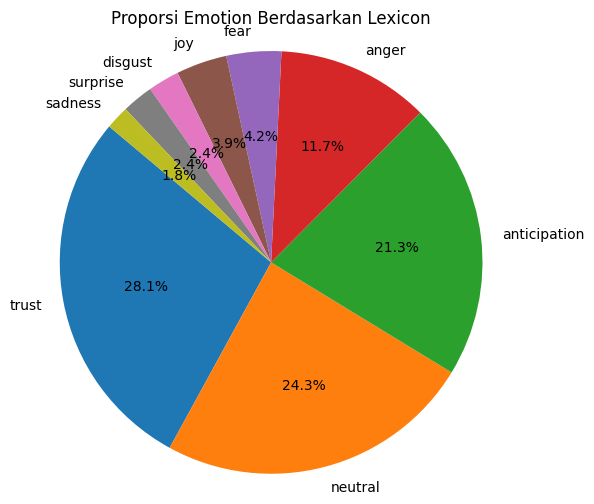

In [32]:
#Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    emotions_counts,
    labels=emotions_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Proporsi Emotion Berdasarkan Lexicon')
plt.axis('equal')
plt.show()
     

In [33]:
def generate_wordcloud(text_series, title):
    text = " ".join(text_series)
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

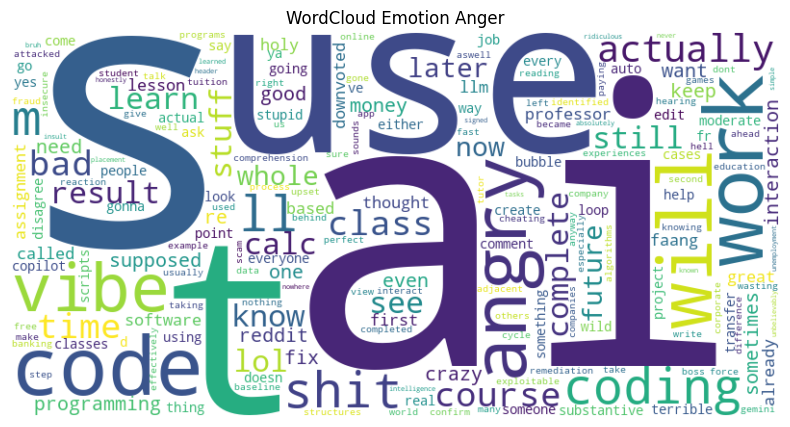

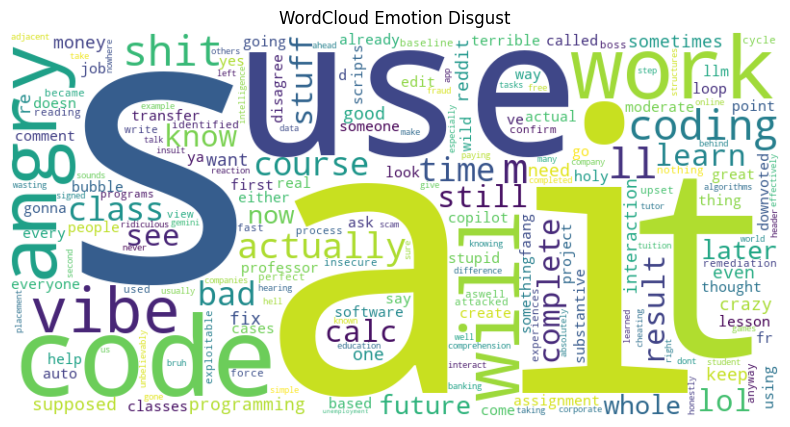

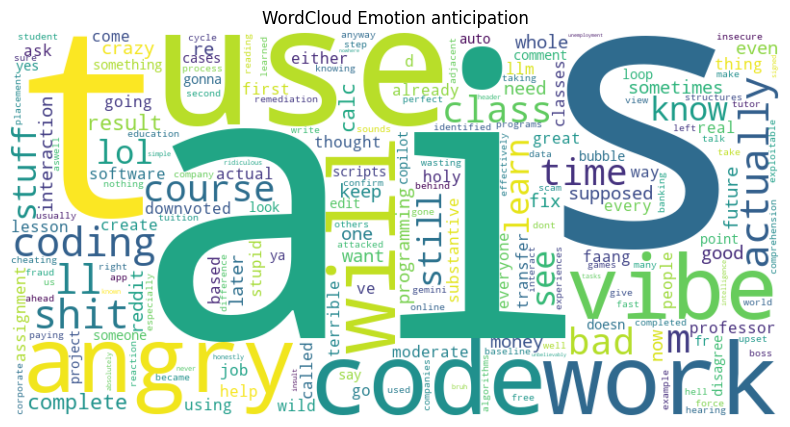

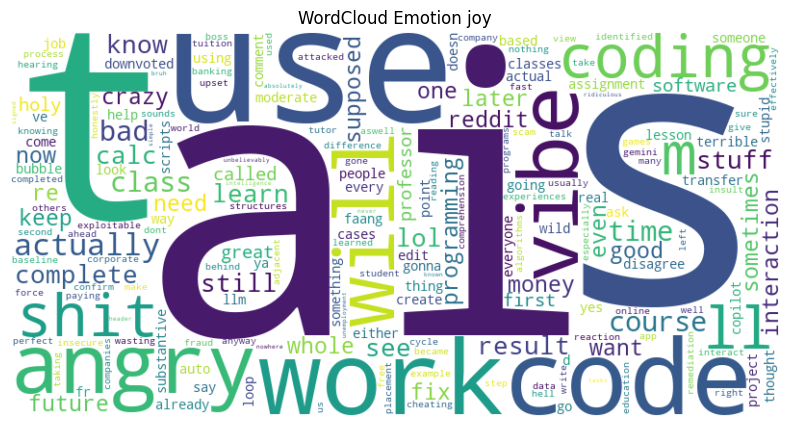

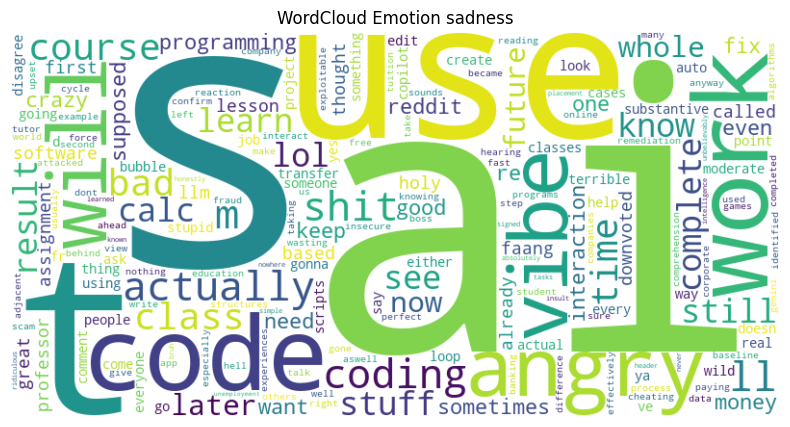

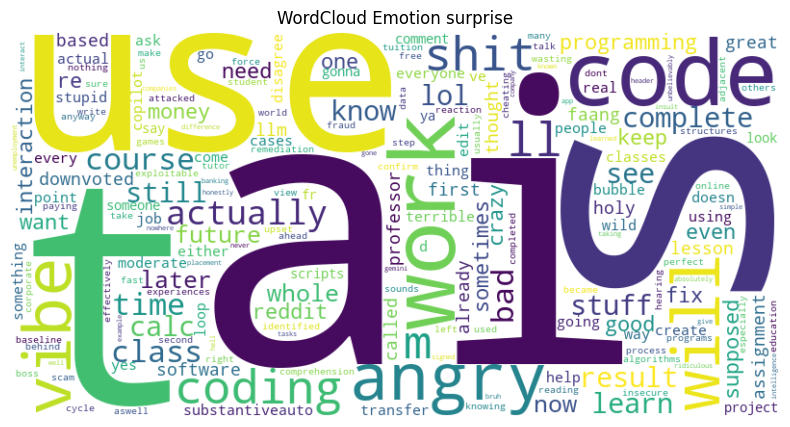

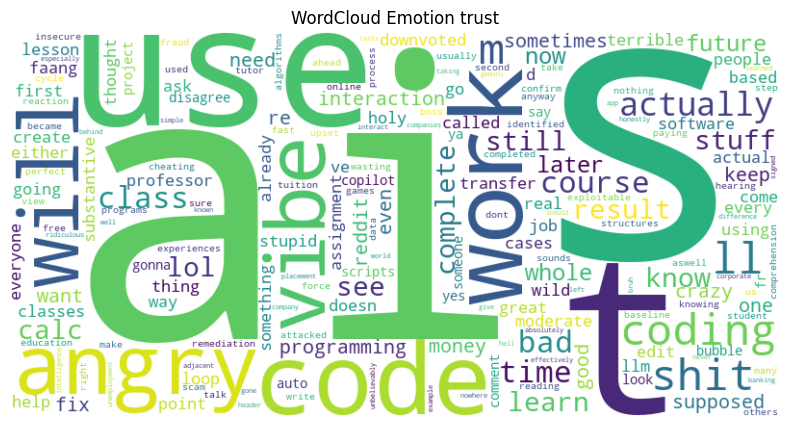

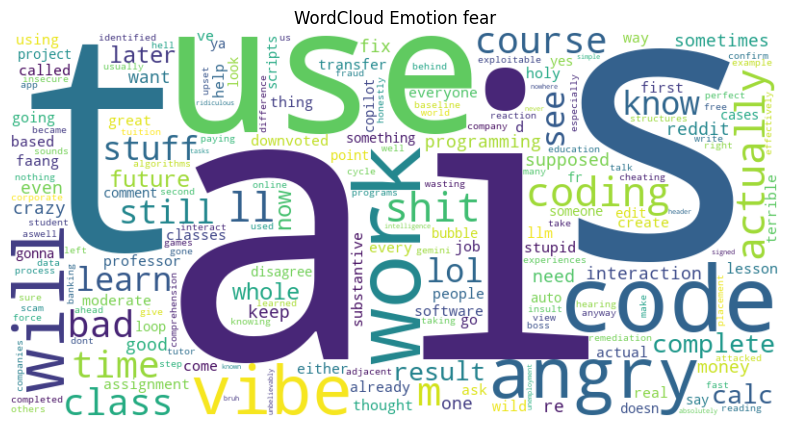

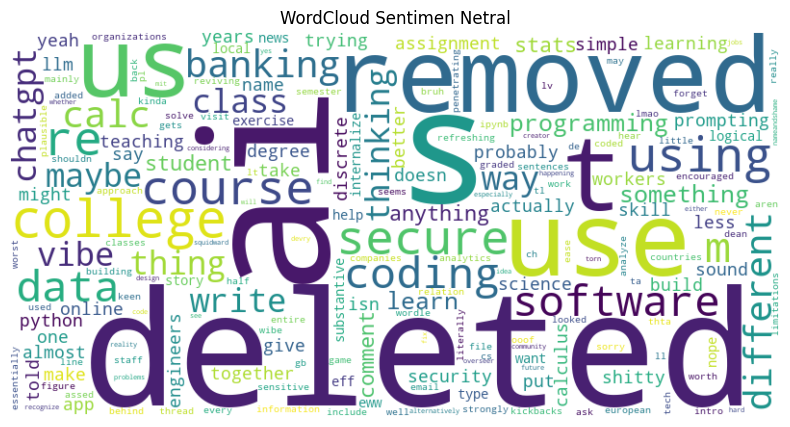

In [34]:
anger_text = df[df['label'] == 'anger']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion Anger")

disgust_text = df[df['label'] == 'disgust']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion Disgust")

anticipation_text = df[df['label'] == 'anticipation']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion anticipation")

joy_text = df[df['label'] == 'joy']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion joy")

sadness_text = df[df['label'] == 'sadness']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion sadness")

surprise_text = df[df['label'] == 'surprise']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion surprise")

trust_text = df[df['label'] == 'trust']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion trust")

fear_text = df[df['label'] == 'fear']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion fear")


# Wordcloud untuk sentimen netral
neutral_text = df[df['label'] == 'neutral']['clean_text']
generate_wordcloud(neutral_text, "WordCloud Sentimen Netral")

In [35]:
df.to_csv("reddit_comments_labeled.csv", index=False)

In [ ]:
# Lakukan Proses TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)

label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 2].index
df_filtered = df[df['label'].isin(valid_labels)].copy()

if df_filtered.empty:
    raise ValueError('Tidak ada label dengan minimal 2 sampel untuk training. Periksa distribusi label.')

X = vectorizer.fit_transform(df_filtered['clean_text'])
y = df_filtered['label']

In [37]:
# Buat Training / Test Split 80 banding 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# SVM Training (Linear SVC)
model = LinearSVC()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

Akurasi: 0.49

=== Classification Report ===
              precision    recall  f1-score   support

       anger       1.00      0.12      0.22         8
anticipation       0.31      0.29      0.30        14
     disgust       0.00      0.00      0.00         2
        fear       0.00      0.00      0.00         3
         joy       0.00      0.00      0.00         3
     neutral       0.57      0.75      0.65        16
     sadness       0.00      0.00      0.00         1
    surprise       0.00      0.00      0.00         1
       trust       0.50      0.84      0.63        19

    accuracy                           0.49        67
   macro avg       0.26      0.22      0.20        67
weighted avg       0.46      0.49      0.42        67



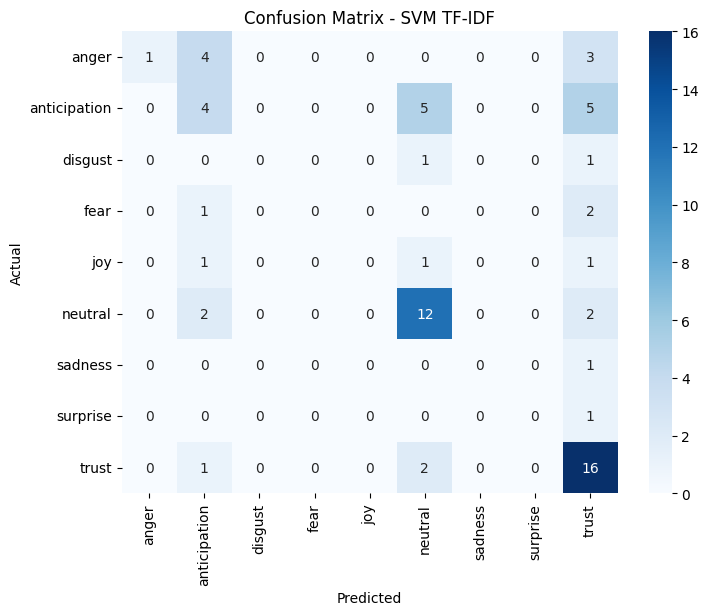

In [38]:
# Evaluasi Model
y_pred = model.predict(X_test)

print(f"Akurasi: {accuracy_score(y_test, y_pred):.2f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM TF-IDF')
plt.show()

In [41]:
sample_text = [
    "Hmmm. Interesting take",
    "Vibe teaching is a huge problem. same at my uni",
    "That last part is hilarious"
]

sample_vec = vectorizer.transform(sample_text)
preds = model.predict(sample_vec)

for t, p in zip(sample_text, preds):
    print(f"{t} --> {p}")

Hmmm. Interesting take --> neutral
Vibe teaching is a huge problem. same at my uni --> fear
That last part is hilarious --> joy
